In [1]:
import numpy as np
import scipy as sp
from pyrtid.utils import NDArrayFloat, finite_gradient
import matplotlib.pyplot as plt

from __future__ import annotations

import logging
from abc import abstractmethod
from time import time
from typing import Callable, List, Optional, Tuple, Union

from numpy.random import Generator, RandomState
from scipy._lib._util import check_random_state  # To handle random_state
from scipy.linalg import solve
from scipy.sparse import csc_array, csr_array
from scipy.sparse.linalg import LinearOperator, eigsh, gmres, lgmres
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist

from pyrtid.inverse.regularization.dense import generate_dense_matrix
from pyrtid.inverse.regularization.hmatrix import Hmatrix
from pyrtid.inverse.regularization.toeplitz import create_row, toeplitz_product
from pyrtid.utils.operators import get_super_ilu_preconditioner
from pyrtid.utils.types import NDArrayFloat, NDArrayInt

In [2]:
ne = 20  # number of members in the ensemble
ns = 100  # number of parameters adjusted
param_ensemble_old = np.random.default_rng(2021).random((ns, ne))
param_ensemble = np.random.default_rng(2023).random((ns, ne))


def obj_fun(xi: NDArrayFloat) -> float:
    return np.sum(xi**2)


def gradient(xi: NDArrayFloat) -> NDArrayFloat:
    return finite_gradient(xi, obj_fun, eps=1e-6)


gradient_ensemble = np.zeros((ns, ne))
for i in range(ne):
    gradient_ensemble[:, i] = gradient(param_ensemble[:, i])

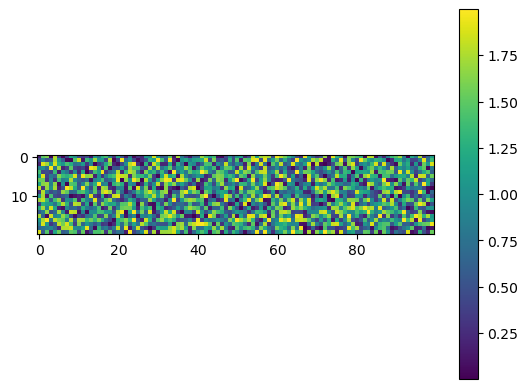

In [3]:
plt.imshow(gradient_ensemble.T)
plt.colorbar()

In [4]:
# on definit une matrice de transition

A = (param_ensemble - param_ensemble.mean(axis=1, keepdims=True)) / np.sqrt(ne - 1)
A.shape

(100, 20)

In [5]:
def obj_fun2(wi: NDArrayFloat, idx: int) -> float:
    return obj_fun(param_ensemble[:, idx] + A @ wi)


def gradient2(wi: NDArrayFloat, idx: int) -> NDArrayFloat:
    return finite_gradient(wi, obj_fun2, fm_args=(idx,), eps=1e-6)


gradient_ensemble2 = np.zeros((ne, ne))
for i in range(ne):
    gradient_ensemble2[:, i] = gradient2(np.zeros(ne), i)

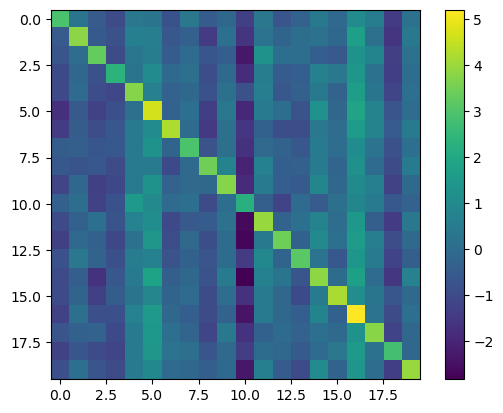

In [6]:
plt.imshow(gradient_ensemble2.T)
plt.colorbar()

In [7]:
(A.T @ gradient_ensemble).shape

(20, 20)

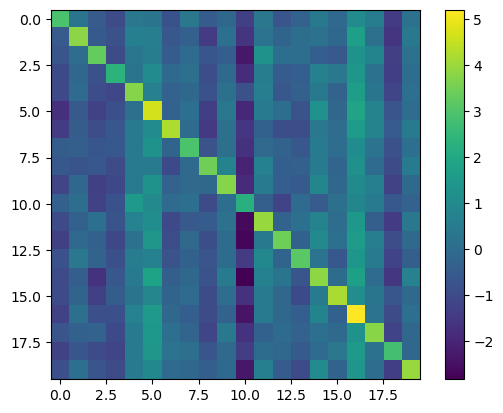

In [8]:
plt.imshow((A.T @ gradient_ensemble).T)
plt.colorbar()

In [9]:
(A @ np.ones(ne)).shape

(100,)

## Regularization term

In [10]:
class CallBack:
    """Represents a callback instance."""

    __slots__: List[str] = ["res"]

    def __init__(self) -> None:
        """Initialize the instance."""
        self.res: List[NDArrayFloat] = []

    def __call__(self, rk) -> None:
        self.res.append(rk)

    @property
    def itercount(self) -> int:
        """Return the number of times the callback as been called."""
        return len(self.res)

    def clear(self) -> None:
        """Delete all results."""
        self.res = []


class EnsembleCovarianceMatrix(LinearOperator):
    r"""
    Represents a covariance matrix as an ensemble of realizations.

    For a given ensemble with shape (:math:`N_{s}`, :math:`N_{e}`), the number of
    points and the number of members in the ensemble respectively, the covariance
    matrix :math:`\mathbf{\Sigma_{ss}}` is approximated from the ensemble
    in the standard way of EnKF
    :cite:p:`evensenDataAssimilationEnsemble2007,aanonsenEnsembleKalmanFilter2009`:

    .. math::
        \mathbf{\Sigma_{ss}} = \frac{1}{N_{e} - 1} \sum_{j=1}^{N_{e}}\left(s_{j} -
        \overline{s}\right)\left(s_{j}
        - \overline{s^{l}} \right)^{T}

    Or by defining a matrix of anomalies
    :math:`\mathbf{A} = \mathbf{S} - \overline{\mathbf{S}}`
    with shape  (:math:`N_{s}`, :math:`N_{e}`):

    .. math::
        \mathbf{\Sigma_{ss}} = \frac{1}{N_{e} - 1} \mathbf{A}^{T}\mathbf{A}

    Note
    ----
    Practically, the dense covariance matrix is never built,
    only the anomalies matrix :math:`\mathbf{A}` is used. The product between the
    inverse of the covariance matrix and a vector
    :math:`\mathbf{x} = \mathbf{\Sigma_{ss}}^{-1}\mathbf{b}`
    is obtained solving the system :math:`\mathbf{A}^{T}\mathbf{Ax} = \mathbf{b}`,
    using gmres, where only anomalies matrix vector products are required.
    """

    def __init__(
        self,
        ensemble: NDArrayFloat,
    ) -> None:
        """
        Initiate the instance.

        Parameters
        ----------
        ensemble : NDArrayFloat
            Ensemble of realization with shape (:math:`N_{s}`, :math:`N_{e}`).
        """
        # counters
        self.count: int = 0
        self.solvmatvecs: int = 0
        super().__init__(dtype="d", shape=(ensemble.shape[0], ensemble.shape[0]))
        self.ensemble = ensemble

    @property
    def anomalies(self) -> NDArrayFloat:
        """
        Return the matrix of anomalies.

        """
        return self.ensemble - np.mean(self.ensemble, axis=1, keepdims=True)

    @property
    def n_ens(self) -> int:
        """Return the number of members in the ensemble."""
        return self.ensemble.shape[0]

    def matvec(self, x: NDArrayFloat) -> NDArrayFloat:
        """Return the covariance matrix times the vector x (dot product)."""
        return np.linalg.multi_dot([self.anomalies, self.anomalies.T, x]) / (
            self.n_ens - 1
        )  # type: ignore

    def todense(self) -> NDArrayFloat:
        """
        Return a dense representation of the matrix.
        """
        return self.anomalies @ self.anomalies.T / (self.n_ens - 1)

    def _matvec(self, x: NDArrayFloat) -> NDArrayFloat:
        """Return the covariance matrix times the vector x."""
        return self.matvec(x)

    def solve(
        self, b: NDArrayFloat, tol: float = 1e-12, maxiter: int = 1000
    ) -> NDArrayFloat:
        """
        Solve A^{T}Ax = b, with A, the anomalies matrix instance.

        Note that the dense covariance matrix is never built.
        """
        residual = CallBack()
        x, info = gmres(
            self,
            b,
            tol=tol,
            maxiter=maxiter,
            callback=residual,
            atol=1e-12,
            callback_type="legacy",
        )
        self.solvmatvecs += residual.itercount
        return x

    def get_diagonal(self) -> NDArrayFloat:
        """Return the diagonal entries of the matrix (variances)."""
        return np.sum((self.anomalies**2), axis=0) / (self.n_ens - 1.0)

    def get_trace(self) -> float:
        """Return the trace of the covariance matrix."""
        return float(np.sum(self.get_diagonal()))

In [11]:
mat = EnsembleCovarianceMatrix(param_ensemble)

In [12]:
param_ensemble.mean(axis=1)

array([0.50224   , 0.64486329, 0.51336755, 0.43752797, 0.55163282,
       0.49527464, 0.47645081, 0.48425679, 0.55445321, 0.49606501,
       0.37680125, 0.48272432, 0.43193083, 0.41884162, 0.54075165,
       0.46569867, 0.51725187, 0.47043711, 0.44404685, 0.33071342,
       0.60693566, 0.47183321, 0.43505165, 0.56264963, 0.53620204,
       0.38168722, 0.38050182, 0.56659309, 0.50358414, 0.45610978,
       0.47876553, 0.51420771, 0.56314276, 0.56186454, 0.50608555,
       0.43458866, 0.55011814, 0.46262043, 0.47787583, 0.46137553,
       0.5108657 , 0.52239734, 0.53648641, 0.46605034, 0.48633966,
       0.49402474, 0.4651526 , 0.49623248, 0.44228947, 0.45761781,
       0.48208018, 0.48725434, 0.4585938 , 0.53055815, 0.60965144,
       0.4817223 , 0.56297829, 0.6313596 , 0.37722389, 0.4552697 ,
       0.58957464, 0.64338443, 0.55752923, 0.48982   , 0.49766525,
       0.50935906, 0.51597019, 0.36621902, 0.58421153, 0.35864973,
       0.53011115, 0.44011603, 0.52746873, 0.4307426 , 0.51900

In [13]:
def obj_fun_reg(xi: NDArrayFloat, idx: int) -> float:
    residuals = xi - param_ensemble[:, idx]
    return float(
        0.5
        * np.dot(
            residuals.T,
            mat.solve(residuals),
        )
    )


def gradient_reg(xi: NDArrayFloat, idx: int) -> NDArrayFloat:
    return finite_gradient(xi, obj_fun_reg, fm_args=(idx,), eps=1e-6)


# gradient_ensemble_reg = np.zeros((ns, ne))
# for i in range(ne):
#     print(i)
#     gradient_ensemble_reg[:, i] = gradient_reg(param_ensemble[:, i], i)